In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
pranavuikey_black_friday_sales_eda_path = kagglehub.dataset_download('pranavuikey/black-friday-sales-eda')

print('Data source import complete.')


/Users/user/AI_Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/user/AI_Project/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


**Import important libraries and modules**

In [2]:
pranavuikey_black_friday_sales_eda_path

'/Users/user/.cache/kagglehub/datasets/pranavuikey/black-friday-sales-eda/versions/1'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore


# Inspecting The Data

In [4]:
df=pd.read_csv(f"{pranavuikey_black_friday_sales_eda_path}"+'/train.csv')

In [5]:
df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [7]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [8]:
### NaN qiymatlarni moda bilan toldiramiz, sababi kategorical

In [9]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [10]:
df.describe(include='object')

,Product_ID,Gender,Age,City_Category,Stay_In_Current_City_Years
count,550068,550068,550068,550068,550068
unique,3631,2,7,3,5
top,P00265242,M,26-35,B,1
freq,1880,414259,219587,231173,193821


In [11]:
df.duplicated().sum()

np.int64(0)

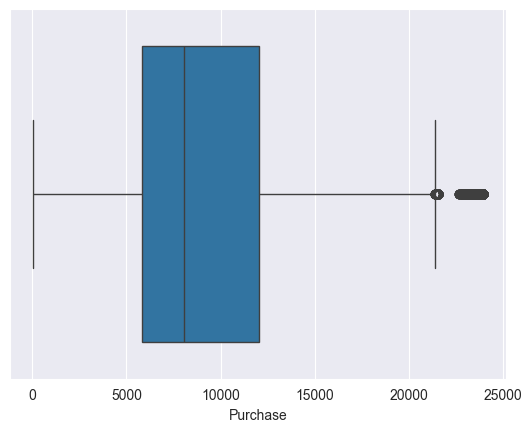

In [12]:
sns.boxplot(x=df['Purchase'])
plt.show()

In [13]:
df['zscore_Purchase'] = zscore(df['Purchase'])
df_outliers = df[(df['zscore_Purchase'] > 3 )|(df['zscore_Purchase'] < -3 )]

df_outliers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,zscore_Purchase


In [14]:
bin_edges = range(1, 25000, 5000)
labels = ["{0}-{1}".format(i, i + 4999) for i in range(1, 20000, 5000)]
df['Purchase_Binned'] = pd.cut(df['Purchase'], bins=bin_edges,right=False, labels=[1,2,3,4])
df.head()


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,zscore_Purchase,Purchase_Binned
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370,-0.177973,2
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200,1.181756,4
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422,-1.561193,1
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057,-1.633858,1
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969,-0.257805,2


In [15]:
df['Purchase_Binned'].nunique()

4

In [16]:
def ages(value):

    if '0-17' in value:
        value = value.replace('0-17','Child')
        return str(value)
    elif '18-25' in value:
        value = value.replace('18-25','Tennager')
        return str(value)
    elif '26-35' in value:
        value = value.replace('26-35','Adult')
        return str(value)
    elif '36-45' in value:
        value = value.replace('36-45','Adult')
        return str(value)
    elif '46-50' in value:
        value = value.replace('46-50','Adult')
        return str(value)
    elif '51-55' in value:
        value = value.replace('51-55','Old')
        return str(value)
    else:
        value = value.replace('55+','Old')
        return str(value)

df['Age'] = df['Age'].apply(ages)
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,zscore_Purchase,Purchase_Binned
0,1000001,P00069042,F,Child,10,A,2,0,3,NaN,NaN,8370,-0.177973,2
1,1000001,P00248942,F,Child,10,A,2,0,1,6.0,14.0,15200,1.181756,4
2,1000001,P00087842,F,Child,10,A,2,0,12,NaN,NaN,1422,-1.561193,1
3,1000001,P00085442,F,Child,10,A,2,0,12,14.0,NaN,1057,-1.633858,1
4,1000002,P00285442,M,Old,16,C,4+,0,8,NaN,NaN,7969,-0.257805,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,Old,13,B,1,1,20,NaN,NaN,368,-1.771025,1
550064,1006035,P00375436,F,Adult,1,C,3,0,20,NaN,NaN,371,-1.770428,1
550065,1006036,P00375436,F,Adult,15,B,4+,1,20,NaN,NaN,137,-1.817013,1
550066,1006038,P00375436,F,Old,1,C,2,0,20,NaN,NaN,365,-1.771623,1


In [17]:
df["Age"].value_counts()

Age
Adult       375301
Tennager     99660
Old          60005
Child        15102
Name: count, dtype: int64

In [18]:
df["City_Category"].value_counts()

City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

In [19]:
purchase_sums = df.groupby("City_Category")["Purchase"].sum()
purchase_sums

City_Category
A    1316471661
B    2115533605
C    1663807476
Name: Purchase, dtype: int64

In [20]:
df["Stay_In_Current_City_Years"].value_counts()

Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64

# Cleaning And Preprocessing Data

In [21]:
replaceNulls = {
 "Product_Category_2" : df["Product_Category_2"].mode()[0],
 "Product_Category_3" : df["Product_Category_3"].mode()[0]
}
df.fillna(replaceNulls,inplace=True)

In [22]:
df["Marital_Status"] = df["Marital_Status"].apply(lambda x: "Married" if x == 1 else "Single")

# EDA And Data Visualization

**Set a global palette**

In [23]:
sns.set_palette("colorblind")

**We can derive that the max purchase is done by Males and age between 26 and 35.**

In [24]:
df.loc[df["Purchase"]==df["Purchase"].max()]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,zscore_Purchase,Purchase_Binned
87440,1001474,P00052842,M,Adult,4,A,2,Married,10,15.0,16.0,23961,2.925911,NaN
93016,1002272,P00052842,M,Adult,0,C,1,Single,10,15.0,16.0,23961,2.925911,NaN
370891,1003160,P00052842,M,Adult,17,C,3,Single,10,15.0,16.0,23961,2.925911,NaN


In [25]:
# Unique Customers from data
df['User_ID'].nunique()

5891

In [26]:
# Grouping data based on the userid
Sales_grouped_data = df.groupby('User_ID').agg(
                        total_order = ("User_ID","count"),
                        total_amount_spent = ("Purchase","sum"),
                        average_amount_spent = ("Purchase","mean")
                        ).reset_index()

Sales_grouped_data['User_ID'] = Sales_grouped_data['User_ID'].astype(str)
Sales_grouped_data

,User_ID,total_order,total_amount_spent,average_amount_spent
0,1000001,35,334093,9545.514286
1,1000002,77,810472,10525.610390
2,1000003,29,341635,11780.517241
3,1000004,14,206468,14747.714286
4,1000005,106,821001,7745.292453
...,...,...,...,...
5886,1006036,514,4116058,8007.894942
5887,1006037,122,1119538,9176.540984
5888,1006038,12,90034,7502.833333
5889,1006039,74,590319,7977.283784


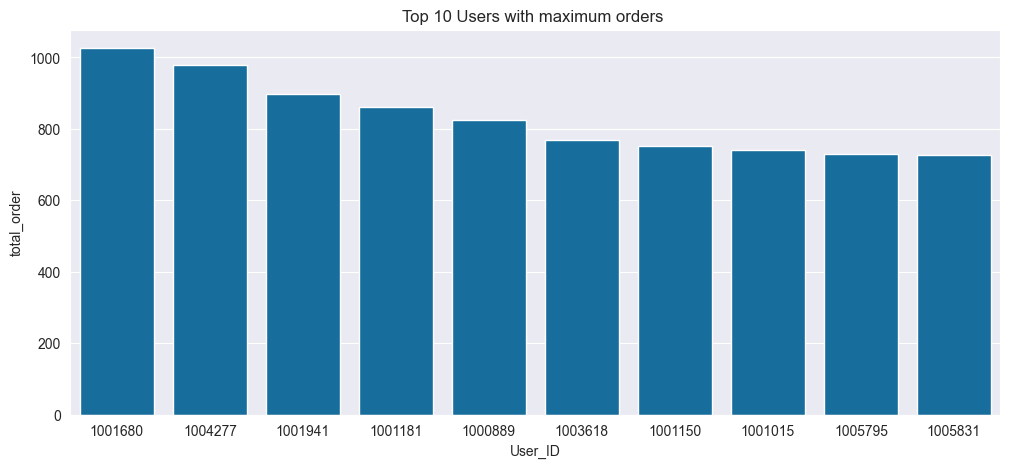

In [27]:
# Top 10 User_id with maximum orders
plt.figure(figsize=(12,5))

plt.title("Top 10 Users with maximum orders ")
sns.barplot(data=Sales_grouped_data.sort_values(by="total_order", ascending=False).head(10),
            x='User_ID', y='total_order')
plt.show()

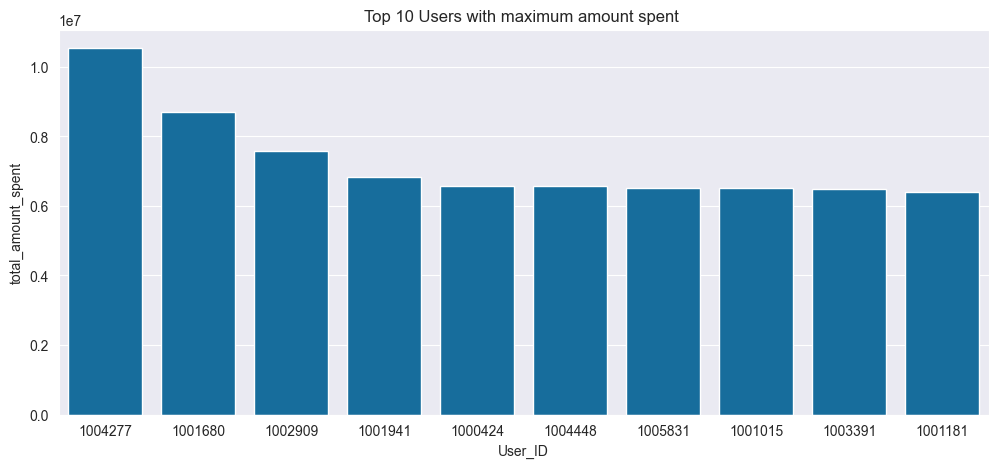

In [28]:
# Top 10 Users with maximum amount spent
plt.figure(figsize=(12,5))

plt.title("Top 10 Users with maximum amount spent ")
sns.barplot(data=Sales_grouped_data.sort_values(by="total_amount_spent", ascending=False).head(10),
            x='User_ID', y='total_amount_spent')
plt.show()

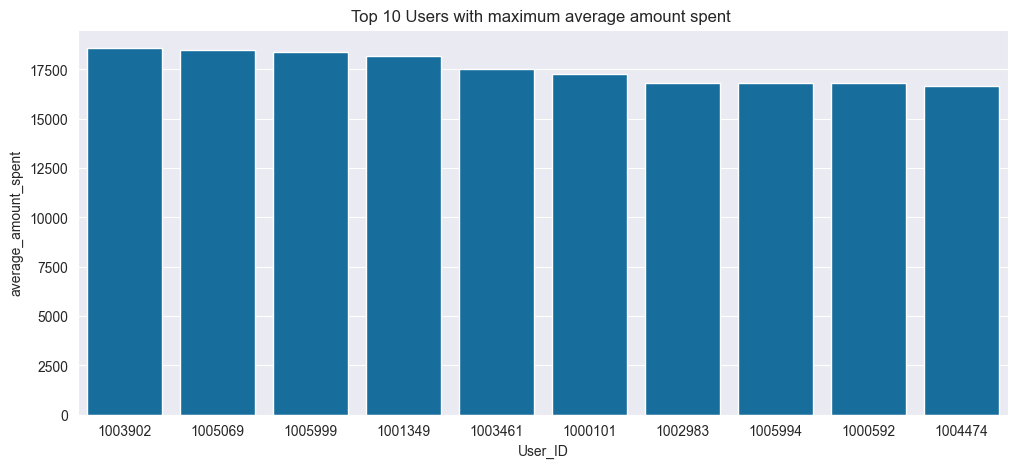

In [29]:
# Top 10 Users with maximum average amount spent
plt.figure(figsize=(12,5))

plt.title("Top 10 Users with maximum average amount spent ")
sns.barplot(data=Sales_grouped_data.sort_values(by="average_amount_spent", ascending=False).head(10),
            x='User_ID', y='average_amount_spent')
plt.show()

In [30]:
df['Product_ID'].nunique()

3631

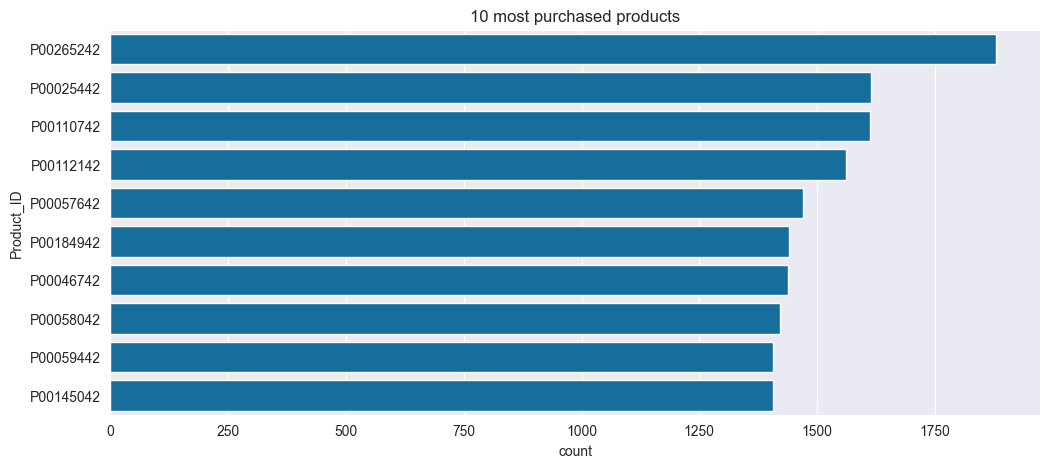

In [31]:
# 10 most purchased products
product_counts = df['Product_ID'].value_counts().reset_index()[:10]

plt.figure(figsize=(12,5))
plt.title("10 most purchased products")
sns.barplot(y=product_counts['Product_ID'], x=product_counts['count'])
plt.show()

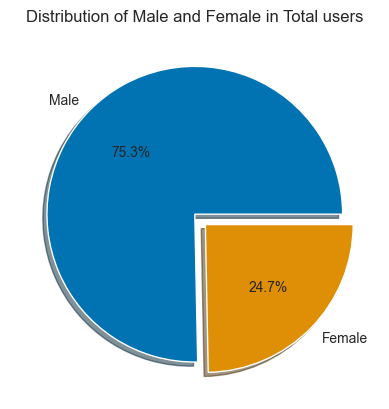

In [32]:
gender_counts = df['Gender'].value_counts()
labels = ['Male','Female']

plt.title("Distribution of Male and Female in Total users")
plt.pie(gender_counts.values, labels=labels,autopct='%.1f%%', shadow=True, explode=[0,0.1])
plt.show()

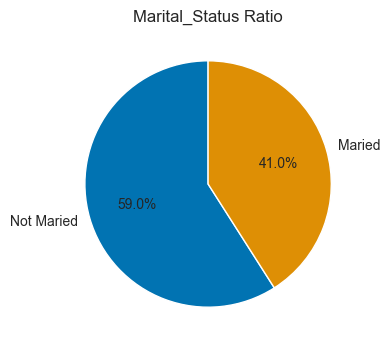

In [33]:
values=df['Marital_Status'].value_counts()
categories = ['Not Maried', 'Maried']
plt.figure(figsize=(4, 4))
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title('Marital_Status Ratio')
plt.show()

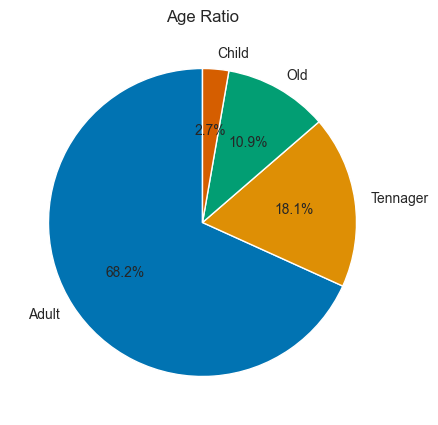

In [34]:
values=df['Age'].value_counts()
categories = ['Adult','Tennager','Old','Child']
plt.figure(figsize=(5,5))
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title('Age Ratio')
plt.show()

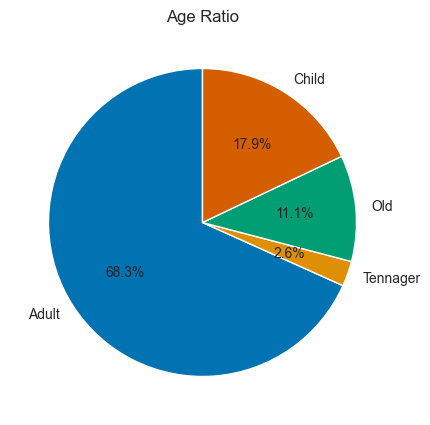

In [36]:
values=df.groupby("Age")["Purchase"].sum()
categories = ['Adult','Tennager','Old','Child']
plt.figure(figsize=(5,5))
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title('Age Ratio')
plt.show()

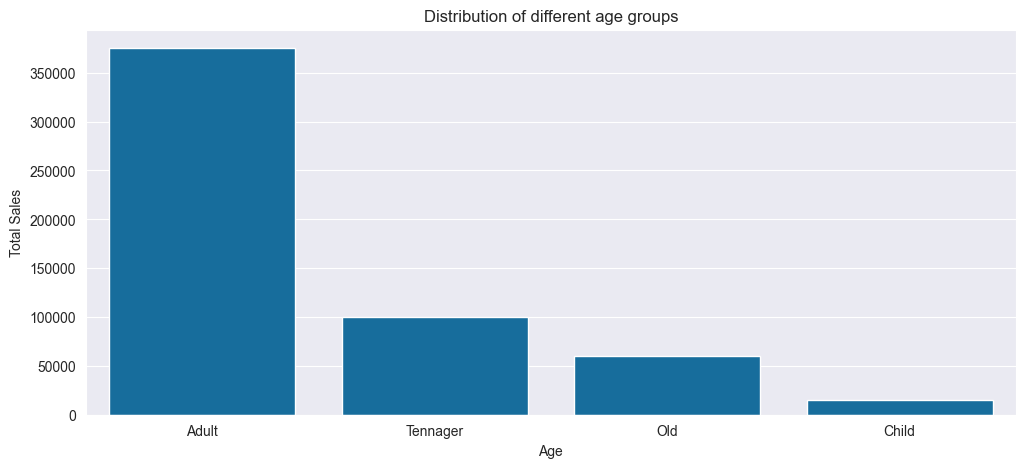

In [43]:
df['Age'].value_counts()
plt.figure(figsize=(12,5))
plt.title("Distribution of different age groups")
sns.barplot(x=df['Age'].value_counts().index, y = df['Age'].value_counts().values)
plt.ylabel("Total Sales")
plt.show()

**Insights from the following two subplots**

* Males have the highest Purchases over diffrent ages
* Category C has the highest purchases over both gendres.
* In males we can see that category B has higher purchases than category A.
* In females Category A and B are almost the same but A is slighlty higher.  





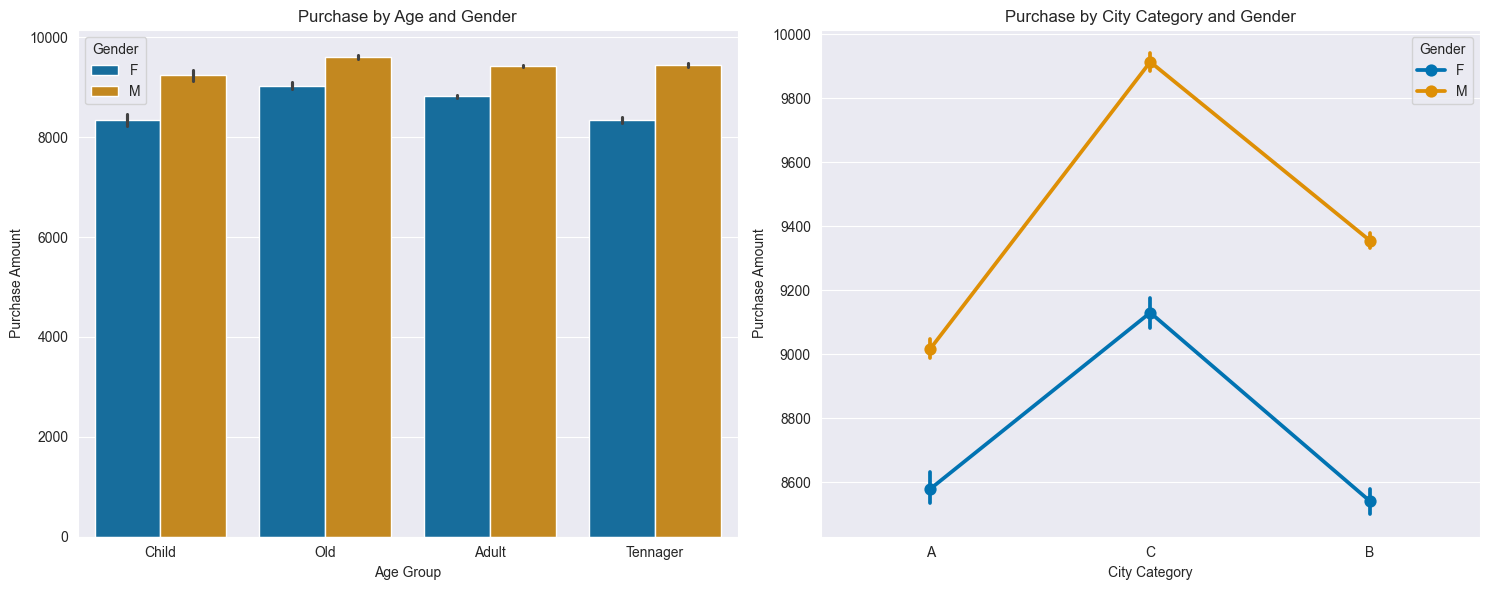

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=df, x="Age", y="Purchase", hue="Gender", ax=axes[0])
axes[0].set_title("Purchase by Age and Gender")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Purchase Amount")

sns.pointplot(data=df, x="City_Category", y="Purchase", hue="Gender", ax=axes[1])
axes[1].set_title("Purchase by City Category and Gender")
axes[1].set_xlabel("City Category")
axes[1].set_ylabel("Purchase Amount")

plt.tight_layout()
plt.show()


**From the following plots We can derive :**


* City category b has the most total purchase amount across all city categories.
* 1 year of staying in current city has the most total purchase amount
compared to other years.




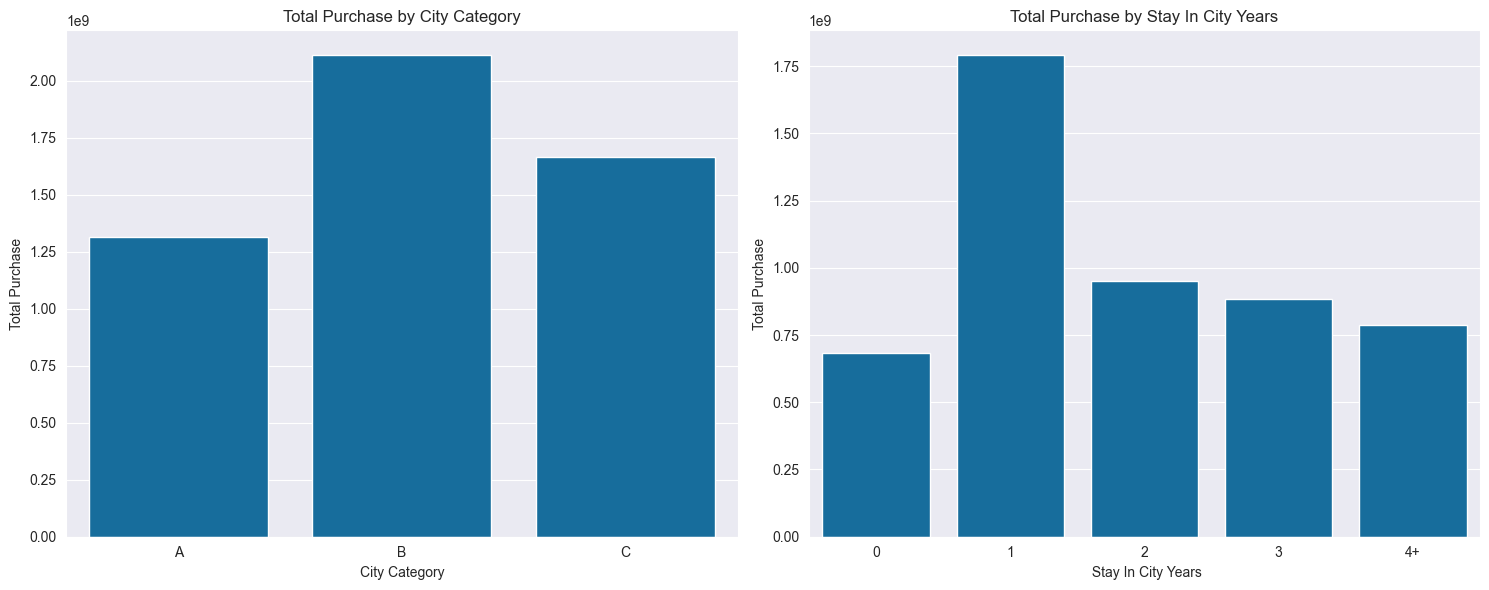

In [45]:
purchase_sums_city_category = df.groupby("City_Category")["Purchase"].sum()
purchase_sums_stay_in_city = df.groupby("Stay_In_Current_City_Years")["Purchase"].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=purchase_sums_city_category.index, y=purchase_sums_city_category.values,ax=axes[0])
axes[0].set_title("Total Purchase by City Category")
axes[0].set_xlabel("City Category")
axes[0].set_ylabel("Total Purchase")

sns.barplot(x=purchase_sums_stay_in_city.index, y=purchase_sums_stay_in_city.values,ax=axes[1])
axes[1].set_title("Total Purchase by Stay In City Years")
axes[1].set_xlabel(" Stay In City Years")
axes[1].set_ylabel("Total Purchase")

plt.tight_layout()
plt.show()

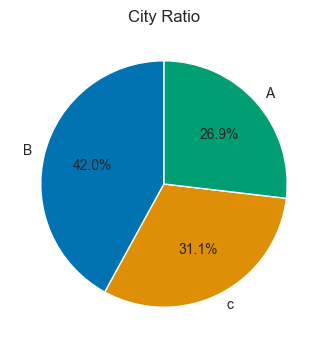

In [46]:
values=df['City_Category'].value_counts()
categories = ['B','c','A']
plt.figure(figsize=(4, 4))
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title('City Ratio')
plt.show()

**Matrix of correlation between numeric values**

<Axes: >

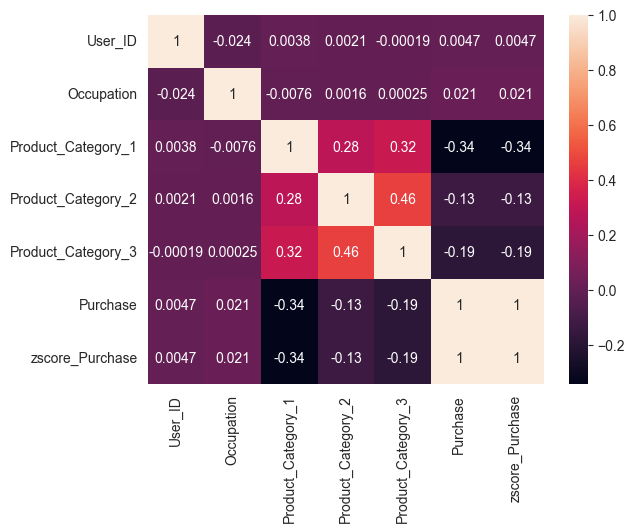

In [47]:
df_num=df.select_dtypes(include=np.number)
sns.heatmap(df_num.corr(),annot=True)

In [48]:
new_df_dummies=pd.get_dummies(df)
new_df_dummies.drop(columns=['zscore_Purchase'],axis=1,inplace=True)
new_df_dummies.head()

,User_ID,Occupation,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Product_ID_P00000142,Product_ID_P00000242,Product_ID_P00000342,Product_ID_P00000442,...,Stay_In_Current_City_Years_1,Stay_In_Current_City_Years_2,Stay_In_Current_City_Years_3,Stay_In_Current_City_Years_4+,Marital_Status_Married,Marital_Status_Single,Purchase_Binned_1,Purchase_Binned_2,Purchase_Binned_3,Purchase_Binned_4
0,1000001,10,3,8.0,16.0,8370,False,False,False,False,...,False,True,False,False,False,True,False,True,False,False
1,1000001,10,1,6.0,14.0,15200,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
2,1000001,10,12,8.0,16.0,1422,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False
3,1000001,10,12,14.0,16.0,1057,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False
4,1000002,16,8,8.0,16.0,7969,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False


In [ ]:
corr_matrix=new_df_dummies.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='Paired')
plt.title('Correlation Matrix Heatmap')
plt.show()

**Top 3 Ages Categories With Most Purchases**

In [ ]:
df_most_ages = df["Age"].value_counts().head(3)
sns.barplot(x=df_most_ages,y=df_most_ages.index)

**Relationship between gender and purchase price with respect to marital status.**

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,x="Gender",y="Purchase",hue="Marital_Status")
plt.title("Purchase by Gender and Marital Status")
plt.show()

In [ ]:
plt.figure(figsize=(15,7))
sns.barplot(data=df,x="Age",y="Purchase",hue="City_Category")
plt.title("Purchase by Age and City Category")
plt.show()

In [ ]:
plt.figure(figsize=(15,7))
sns.barplot(data=df,x="Stay_In_Current_City_Years",y="Purchase",hue="City_Category")
plt.title("Purchase by Stay In Current City Years and City Category")
plt.show()

In [ ]:
sns.barplot(data=df,x="Gender",y="Purchase",hue="Stay_In_Current_City_Years")
plt.title("Purchase by Gender and Stay In Current City Years")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Stay_In_Current_City_Years', data=df)
plt.tight_layout()
plt.show()

In [ ]:
sns.histplot(data=df,x="Purchase",kde=True,bins=15)
plt.title("Purchase Distribution")
plt.show()

In [ ]:
for i, predictor in enumerate(df.drop(columns=["Product_ID",'User_ID','Purchase','zscore_Purchase','Purchase_Binned'])):
    plt.figure(i)
    sns.lineplot(data=df, x=predictor,y='Purchase',marker='o')
    plt.title(f'{predictor} vs Purchase')
    plt.xlabel(f'{predictor} ')
    plt.ylabel('Purchases')
    plt.grid(True)
    plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Occupation', data=df)
plt.show()

**The following three plots show the relation between value of product category and purchase. value**

In [ ]:
sns.relplot(x='Product_Category_1', y='Purchase', kind='line', data=df,height=10, aspect=2)
plt.title("Purchase by Product Category 1")
plt.show()

In [ ]:
sns.relplot(x='Product_Category_2', y='Purchase', kind='line', data=df,height=10, aspect=2)
plt.title("Purchase by Product Category 2")
plt.show()

In [ ]:
sns.relplot(x='Product_Category_3', y='Purchase', kind='line', data=df,height=10, aspect=2)
plt.title("Purchase by Product Category 3")
plt.show()

**Subplots to show the Distribution of diffrent product categories**

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df["Product_Category_1"], bins=15, kde=True)
plt.title("Distribution of Product Category 1")

plt.subplot(1, 3, 2)
sns.histplot(df["Product_Category_2"], bins=15, kde=True)
plt.title("Distribution of Product Category 2")

plt.subplot(1, 3, 3)
sns.histplot(df["Product_Category_3"], bins=15, kde=True)
plt.title("Distribution of Product Category 3")

plt.tight_layout()
plt.show()

In [ ]:
sns.relplot(x='Occupation', y='Purchase', kind='line', data=df, style="Marital_Status" , hue='Gender',height=10, aspect=2)